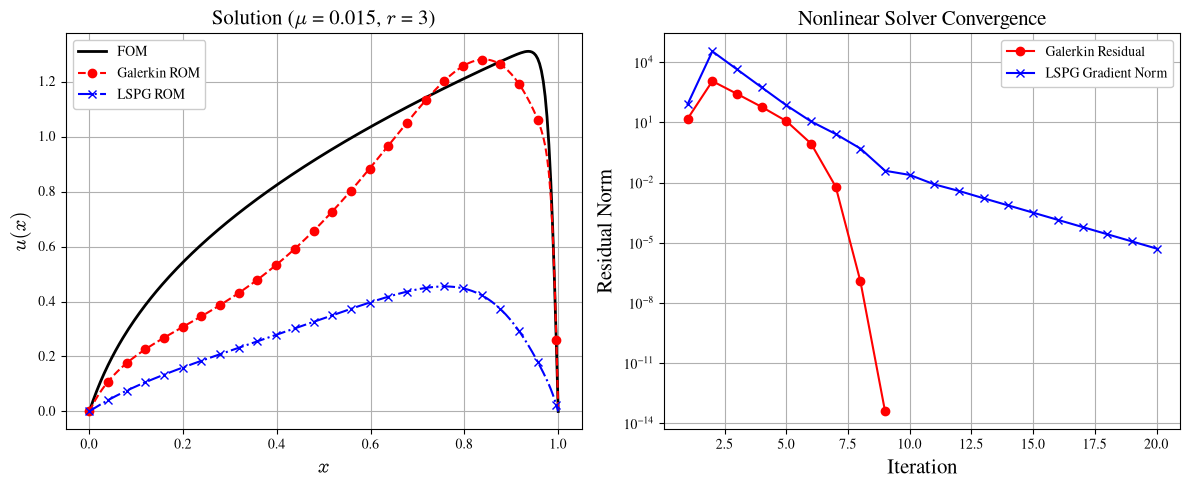

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, solve


# ==========================================
# 1. Set problem
# ==========================================

N = 250                  # Number of inner nodes
L = 1.0                  # Length of domain
dx = L / (N + 1)         # Grid spacing
x = np.linspace(dx, L - dx, N)
f_val = 1.0              # Source term


def compute_R_and_J(u, mu, dx, f):
    u_pad = np.zeros(N + 2)
    u_pad[1:-1] = u

    u_i = u_pad[1:-1]
    u_ip1 = u_pad[2:]
    u_im1 = u_pad[:-2]

    # Residual vector: R
    R = (
        u_i * (u_ip1 - u_im1) / (2 * dx)
        - mu * (u_ip1 - 2 * u_i + u_im1) / (dx**2)
        - f
    )

    # Jacobian matrix: J
    diag = (
        (u_ip1 - u_im1) / (2 * dx)
        + 2 * mu / (dx**2)
    )

    upper = (
        u_i[:-1] / (2 * dx)
        - mu / (dx**2)
    )

    lower = (
        -u_i[1:] / (2 * dx)
        - mu / (dx**2)
    )

    J = (
        np.diag(diag)
        + np.diag(upper, k=1)
        + np.diag(lower, k=-1)
    )

    return R, J


def solve_fom(mu, dx, f, tol=1e-8, max_iter=100):
    u = np.zeros(N)

    for i in range(max_iter):
        R, J = compute_R_and_J(u, mu, dx, f)

        res_norm = np.linalg.norm(R)

        if res_norm < tol:
            break

        du = solve(J, -R)
        u = u + du

    return u


# ==========================================
# 2. Collect snapshots and construct POD basis
# ==========================================

mu_train = [1.0, 0.1, 0.01]
mu_test = 0.015

r = 10

snapshots = []

for mu in mu_train:
    u_snap = solve_fom(mu, dx, f_val)
    snapshots.append(u_snap)

# Snapshot matrix
# Shape: (number of DOFs, number of snapshots)
S = np.column_stack(snapshots)

# Singular Value Decomposition
U, Sigma, Vt = svd(S, full_matrices=False)

# Number of available POD modes cannot exceed
# the number of singular vectors
r = min(r, U.shape[1])

# POD basis
V = U[:, :r]


# ==========================================
# 3. Projection-based ROM
# ==========================================

def solve_rom_galerkin(mu, V, dx, f, tol=1e-8, max_iter=20):
    ur = np.zeros(V.shape[1])
    res_history = []

    for i in range(max_iter):
        # Reconstruction
        u = V @ ur

        # FOM residual and Jacobian
        R, J = compute_R_and_J(u, mu, dx, f)

        # Galerkin projection
        R_r = V.T @ R
        J_r = V.T @ J @ V

        res_norm = np.linalg.norm(R_r)
        res_history.append(res_norm)

        if res_norm < tol:
            break

        # Newton update in reduced space
        dur = solve(J_r, -R_r)
        ur = ur + dur

    return V @ ur, res_history


def solve_rom_lspg(mu, V, dx, f, tol=1e-8, max_iter=20):
    ur = np.zeros(V.shape[1])
    res_history = []

    for i in range(max_iter):
        # Reconstruction
        u = V @ ur

        # FOM residual and Jacobian
        R, J = compute_R_and_J(u, mu, dx, f)

        # LSPG test basis
        W = J @ V

        # Normal equations
        R_r = W.T @ R
        J_r = W.T @ W

        res_norm = np.linalg.norm(R_r)
        res_history.append(res_norm)

        if res_norm < tol:
            break

        # Gauss-Newton update
        dur = solve(J_r, -R_r)
        ur = ur + dur

    return V @ ur, res_history


# ==========================================
# 4. Solve FOM and ROM
# ==========================================

u_fom = solve_fom(
    mu_test,
    dx,
    f_val,
)

u_galerkin, res_gal = solve_rom_galerkin(
    mu_test,
    V,
    dx,
    f_val,
)

u_lspg, res_lspg = solve_rom_lspg(
    mu_test,
    V,
    dx,
    f_val,
)


# ==========================================
# 5. Visualization
# ==========================================

x_plot = np.insert(
    np.append(x, L),
    0,
    0.0,
)


def pad_bc(u):
    return np.insert(
        np.append(u, 0.0),
        0,
        0.0,
    )


# Visualization settings
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": [
            "Times New Roman",
            "Nimbus Roman",
            "Liberation Serif",
        ],
        "mathtext.fontset": "cm",
        "axes.formatter.use_mathtext": True,
        "legend.framealpha": 1.0,
        "figure.figsize": (7.0, 5.0),
        "savefig.dpi": 300,
    }
)


fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(12, 5),
)


# ------------------------------------------
# Solution
# ------------------------------------------

ax1.plot(
    x_plot,
    pad_bc(u_fom),
    "k-",
    label="FOM",
    linewidth=2,
)

ax1.plot(
    x_plot,
    pad_bc(u_galerkin),
    "r--",
    label="Galerkin ROM",
    marker="o",
    markevery=10,
)

ax1.plot(
    x_plot,
    pad_bc(u_lspg),
    "b-.",
    label="LSPG ROM",
    marker="x",
    markevery=10,
)

ax1.set_xlabel(
    r"$x$",
    fontsize=15,
)

ax1.set_ylabel(
    r"$u(x)$",
    fontsize=15,
)

ax1.set_title(
    fr"Solution ($\mu$ = {mu_test}, $r$ = {r})",
    fontsize=15,
)

ax1.legend()
ax1.grid(True)


# ------------------------------------------
# Nonlinear solver convergence
# ------------------------------------------

ax2.semilogy(
    range(1, len(res_gal) + 1),
    res_gal,
    "r-o",
    label="Galerkin Residual",
)

ax2.semilogy(
    range(1, len(res_lspg) + 1),
    res_lspg,
    "b-x",
    label="LSPG Gradient Norm",
)

ax2.set_xlabel(
    "Iteration",
    fontsize=15,
)

ax2.set_ylabel(
    "Residual Norm",
    fontsize=15,
)

ax2.set_title(
    "Nonlinear Solver Convergence",
    fontsize=15,
)

ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()